In [1]:
%%capture
%run '/Users/katiebutler/Downloads/HIR Lab/Python Code - KB/MetabolicCost/metCostMod-Result.ipynb'

In [2]:
# DEFINE DERIVATIVES
import numpy as np

# Time: 0-15
# X: signal with 15 second
# Ver: x_1

def num_derivative(time, x, ver):
    if ver.lower() == 'x_1':
        version = 2
        x = np.reshape(x, (-1, 1))
    else:
        raise ValueError('Not a valid version')

    delta_t = np.mean(np.diff(time))  # sampling time
    W = 4  # size of the window to be used for the derivative, how many points on either side of center point
    N = 3   # order of interpolating polynomial
    K = round(W / 2)  # center node
    A = np.linspace(-W, 0, W + 1) + K
    A = np.vstack([A * delta_t**n for n in range(N+1)]).T
    R = np.zeros(N+1)
    R[1] = 1
    R = R @ np.linalg.pinv(A.T @ A) @ A.T

    if version != 3:
        x_d = np.zeros_like(x)
    else:
        x_d = {key: np.zeros_like(val) for key, val in x.items()}

    if version == 2:
        for i in range(W - K, len(x) - K):
            x_d[i, :] = R @ x[i - W + K : i + K + 1, 0]
                
    return x_d



In [3]:
import numpy as np
from scipy.signal import convolve

def gaussian_kernel(size, sigma):
    """Create a Gaussian kernel."""
    x = np.linspace(-size // 2, size // 2, size)
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / np.sum(kernel)

def filterSignal_Gaussian(signal, fs, cutoff):
    """
    Filter a signal using a Gaussian kernel and compute its derivative
    using the derivative of the Gaussian.
    """
    # Kernel size: 1-minute window at fs Hz
    kernel_size = int(fs * 60)
    if kernel_size % 2 == 0:
        kernel_size += 1  # make it odd for symmetry

    # Convert cutoff frequency to Gaussian std in samples
    sigma = fs / (2 * np.pi * cutoff)

    # Create kernels
    g_kernel = gaussian_kernel(kernel_size, sigma)

    # Filter signal
    filtered = convolve(signal, g_kernel, mode='same')

    return filtered

In [4]:
analyzed = set()
dfCount = 1
for subject in result.keys():
    indShiftDict = {}
    if subject[0] in analyzed:
        continue
    analyzed.add(subject[0])
    for activity in result.keys():
    
        if activity[1] in indShiftDict:
            continue
            
        if activity[1] not in result[subject[0]]:
            continue

        ind = result[subject[0]][activity[1]]['EMG']['Data'][:, code]
        indShift = np.where((ind[:-1] - ind[1:]) != 0)[0]
        
        
        indShiftDict[activity[1]] = indShift

    # Convert to DataFrame for the subject
    indDF = pd.DataFrame(dict([(key, pd.Series(value)) for key, value in indShiftDict.items()]))
    indDF = indDF.fillna(0)
    
    if dfCount <= 10:
        if dfCount < 10:
            exec(f"Subject0{dfCount} = indDF")
            dfCount += 1
        else:
            exec(f"Subject{dfCount} = indDF")
            dfCount += 1
    
print(Subject01)

   Backwards    Cycling  Incline    Running    Walking
0   359971.0   359999.0   359971   359971.0   359971.0
1   719944.0   719999.0   719944   719944.0   719944.0
2  1079917.0  1079999.0  1079917  1079917.0  1079917.0
3  1439890.0  1439999.0  1439890  1439890.0  1439890.0
4        0.0  1799999.0  1799862        0.0        0.0
5        0.0        0.0  2159835        0.0        0.0


In [69]:
import scipy.signal as sps

def emg_filt(raw):
    emg = raw
    fs = 1000.0
    lowcut = 30.0
    highcut = 350.0
    order = 5
    nyquist = 0.5 * fs 
    
    has_nan = "Yes" if np.isnan(emg).any() else "No"
    # print(f"Channel has NaN: {has_nan}")
    
    # Bandpass filter 30-350 Hz
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = sps.butter(order, [low, high], btype='bandpass')
    filtered = sps.filtfilt(b, a, emg)
    
    # Full-wave rectification
    rectified = np.abs(filtered)
    
    # Low-pass filter 5 Hz and envelope
    cutoff_lp = 5.0  
    low = cutoff_lp / nyquist
    b_lp, a_lp = sps.butter(4, low, btype='low')
    lowPass = sps.filtfilt(b_lp, a_lp, rectified)
    lowPass = sps.hilbert(lowPass)
    
    return lowPass

In [64]:
import numpy as np
from scipy import signal as sps


fs = 1000  # EMG sampling frequency
window_sec = 15
samples_per_window = int(window_sec * fs)
channels = [5, 8, 13, 16]

low = 50
high = 150 
nyquist = fs / 2 
low_c = low / nyquist
high_c = high / nyquist
order = 4
a, b = sps.butter(order, [low_c, high_c], btype='band')

derivativeDf = []


time = np.nan_to_num(result['Subject01']['Walking']['EMG']['Data'][:, 0], nan=0.0)

start_idx = int(360 * fs)
end_idx = int(1440 * fs)

for ch in channels:
    signal_raw = result['Subject01']['Walking']['EMG']['Data'][:, ch]
    signal_filt = np.nan_to_num(emg_filt(signal_raw), nan=0.0)
    
    bin_times = []
    bin_derivs = []

    for b_start in range(start_idx, end_idx, samples_per_window):
        b_end = min(b_start + samples_per_window, end_idx)
        sig_bin = signal_filt[b_start:b_end]
        t_bin = time[b_start:b_end]

        # Filter between 20-200 hz
        deriv = num_derivative(t_bin, sig_bin, 'x_1')
        deriv = deriv.flatten()
        deriv = sps.filtfilt(a, b, deriv)
        
        # Resample at 1 hz
        len_1hz = int(len(deriv) * (1 / 1000))
        deriv_1hz = sps.resample(deriv, len_1hz)

        # Take average across 15 seconds
        bin_derivs.append(np.mean(deriv_1hz))
        bin_times.append(t_bin[0])

    df = pd.DataFrame({
        'Time': bin_times,
        'EMG_derivative': bin_derivs,
        'Subject': 'Subject01',
        'Activity': 'Walking',
        'Channel': ch
    })

    derivativeDf.append(df)


derivatives_df = pd.concat(derivativeDf, ignore_index=True)
# print(derivatives_df)


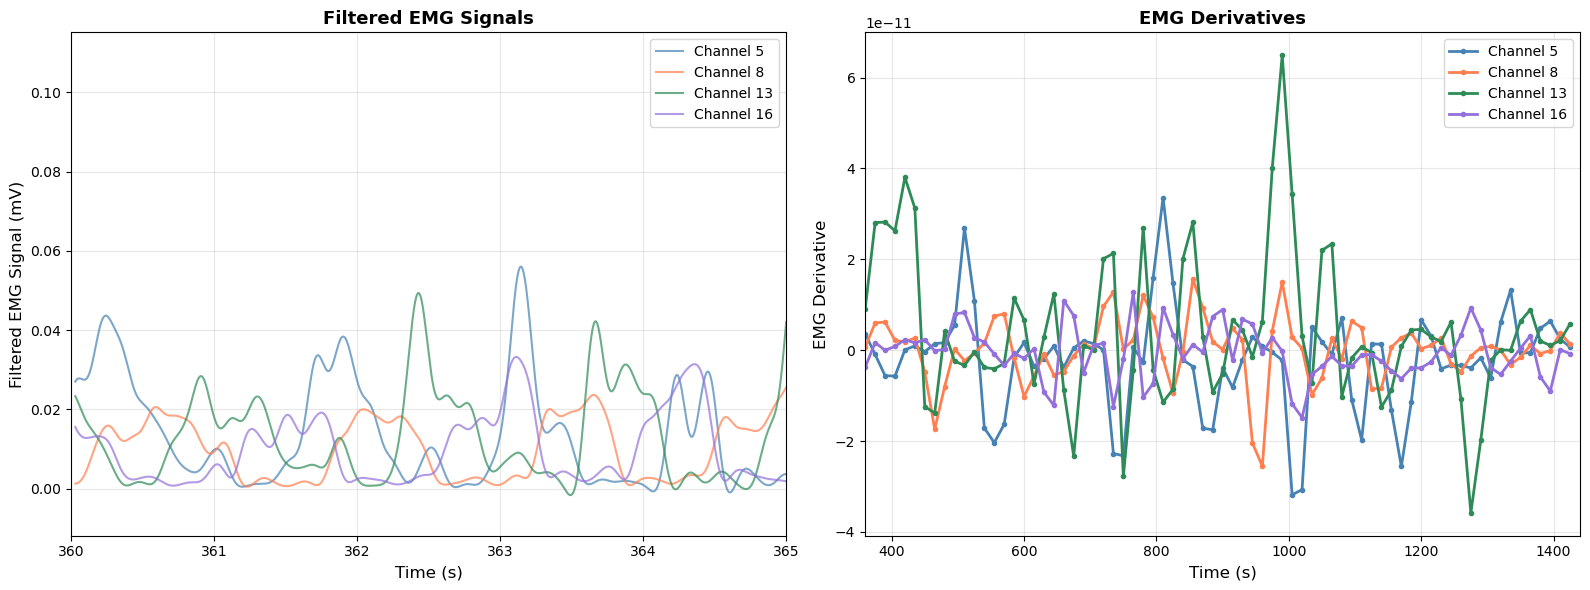

In [71]:
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
# print(derivatives_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

# Left plot: filtered signals
for i, ch in enumerate(channels):
    signal_raw = result['Subject01']['Walking']['EMG']['Data'][:, ch]
    signal_filt = np.nan_to_num(emg_filt(signal_raw), nan=0.0)
    time_full = np.nan_to_num(result['Subject01']['Walking']['EMG']['Data'][:, 0], nan=0.0)
    signal_rect = np.abs(signal_raw)
    
    ax1.plot(time_full[start_idx:end_idx], signal_filt[start_idx:end_idx], 
             color=colors[i], label=f'Channel {ch}', alpha=0.7, linewidth=1.5)

ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Filtered EMG Signal (mV)', fontsize=12)
ax1.set_title('Filtered EMG Signals', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([360, 365])

# Right plot: derivatives
for i, ch in enumerate(channels):
    channel_data = derivatives_df[derivatives_df['Channel'] == ch]
    ax2.plot(channel_data['Time'], channel_data['EMG_derivative'], 
             color=colors[i], label=f'Channel {ch}', linewidth=2, marker='o', markersize=3)

ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('EMG Derivative', fontsize=12)
ax2.set_title('EMG Derivatives', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([360, 1440])

plt.tight_layout()
plt.show()

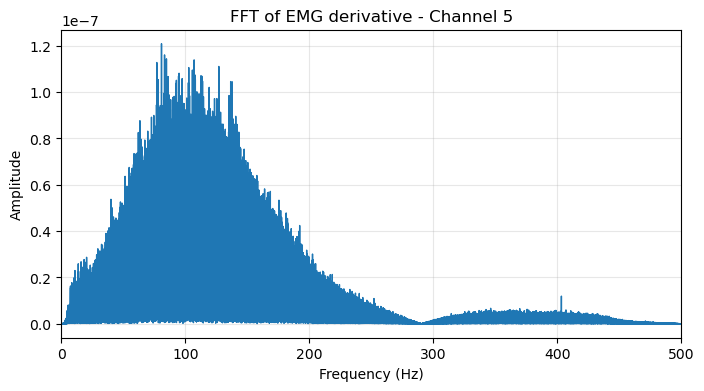

Channel 5 dominant frequency (20-450 Hz): 80.72 Hz


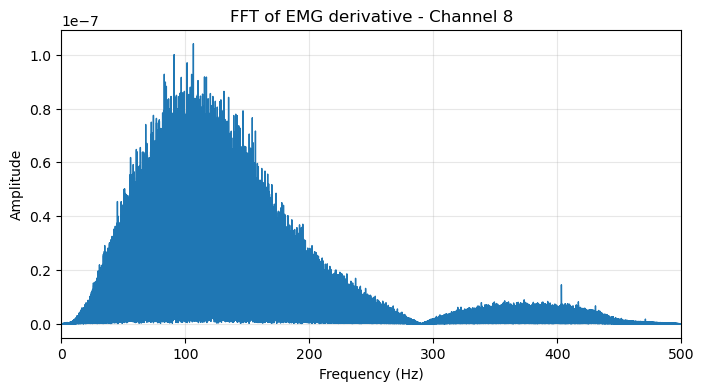

Channel 8 dominant frequency (20-450 Hz): 106.44 Hz


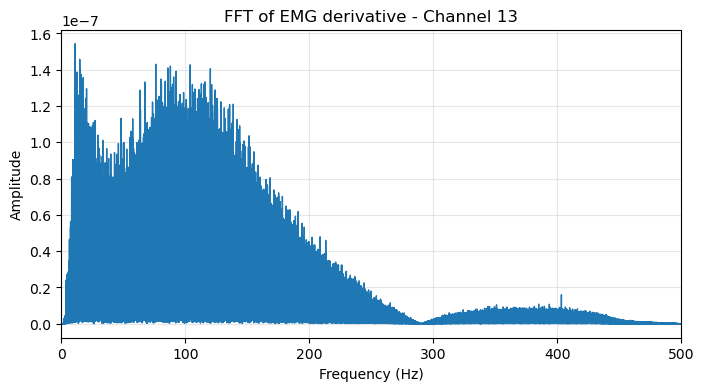

Channel 13 dominant frequency (20-450 Hz): 76.10 Hz


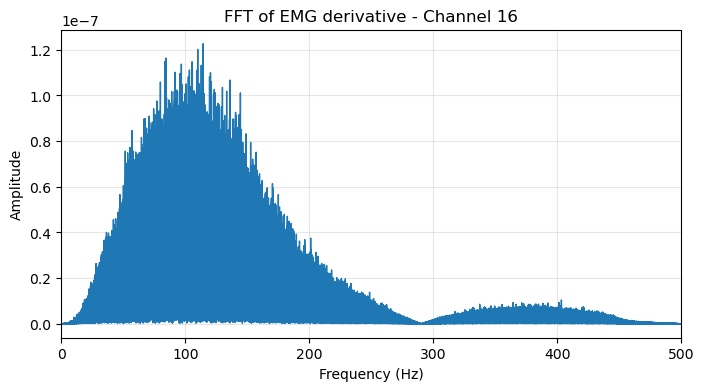

Channel 16 dominant frequency (20-450 Hz): 114.31 Hz


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sps

fs = 1000                     
start_idx = int(360 * fs)     
end_idx   = int(1440 * fs)    
channels = [5, 8, 13, 16]

# Compute dominant freq
def dominant_frequency(freqs, mag, fmin=0.5, fmax=500):
    mask = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(mask):
        return np.nan
    idx = np.argmax(mag[mask])
    return freqs[mask][idx]


for ch in channels:

    time_full = np.nan_to_num(result['Subject01']['Walking']['EMG']['Data'][:, 0], nan=0.0)
    time_seg  = time_full[start_idx:end_idx]                        
    raw_seg   = result['Subject01']['Walking']['EMG']['Data'][start_idx:end_idx, ch]

    deriv_full = num_derivative(time_seg, raw_seg, 'x_1')   
    deriv_full = np.squeeze(deriv_full)                     
    valid_mask = ~np.isnan(deriv_full)
    n = len(deriv_full)
    if n == 0:
        print(f"Channel {ch}: empty derivative, skipping.")
        continue

    fft_vals = np.fft.rfft(deriv_full)
    freqs = np.fft.rfftfreq(n, d=1/fs)  
    fft_mag = np.abs(fft_vals) * (2.0 / n)

    plt.figure(figsize=(8,4))
    plt.plot(freqs, fft_mag, linewidth=1)
    plt.xlim(0, 500)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.title(f'FFT of EMG derivative - Channel {ch}')
    plt.grid(True, alpha=0.3)
    plt.show()

    domf = dominant_frequency(freqs, fft_mag, fmin=20, fmax=450)
    print(f'Channel {ch} dominant frequency (20-450 Hz): {domf:.2f} Hz')
